In [11]:
import os, joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [2]:
!pip install ucimlrepo

In [3]:
from ucimlrepo import fetch_ucirepo

In [5]:
heart_disease = fetch_ucirepo(id=45)

X = heart_disease.data.features
y = heart_disease.data.targets.rename(
    columns={"num":"target"}
    )
y["target"] = (y["target"]>0).astype(int)
print(heart_disease.metadata)

{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

In [7]:
X.isna().sum()

X = X.dropna()

In [8]:
!pip install seaborn

In [12]:
X["thal"] = X["thal"].astype(int)
y = y.loc[X.index]

In [13]:
df = pd.concat([X, y], axis=1)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3,0


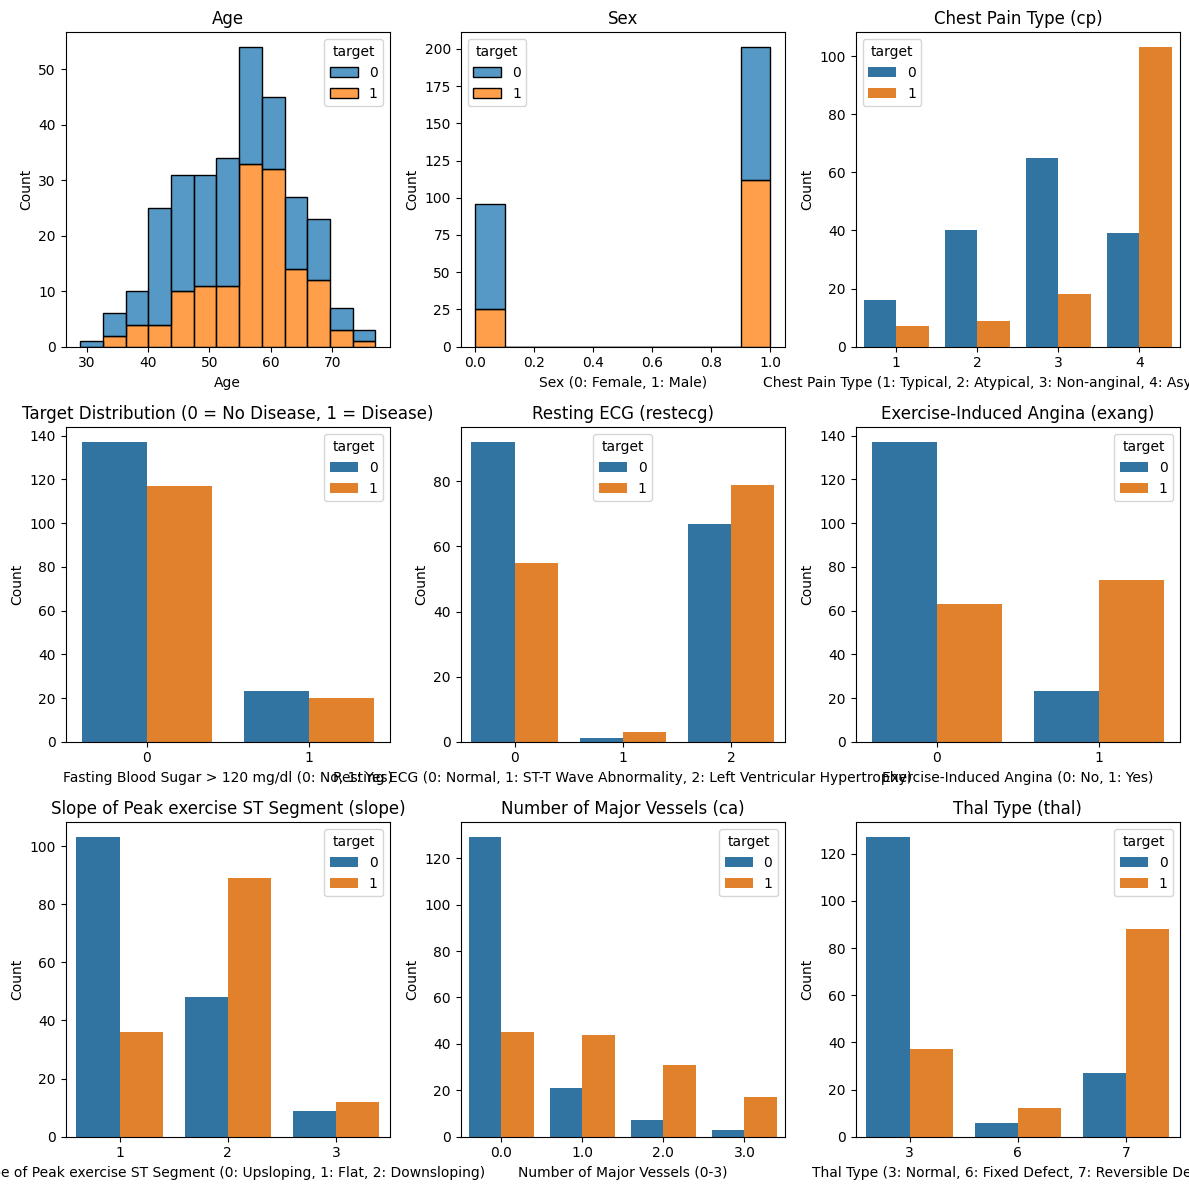

In [14]:
import seaborn as sns

# Plot target variable distribution
plt.figure(figsize=(12, 12))

# Age vs Heart Disease
plt.subplot(3, 3, 1)
sns.histplot(x='age', hue='target', data=df, multiple="stack")
plt.title("Age")
plt.xlabel("Age")
plt.ylabel("Count")

# Sex vs Heart Disease
plt.subplot(3, 3, 2)
sns.histplot(x='sex', hue='target', data=df, multiple="stack")
plt.title("Sex")
plt.xlabel("Sex (0: Female, 1: Male)")
plt.ylabel("Count")

# Chest Pain vs Heart Disease
plt.subplot(3, 3, 3)
sns.countplot(x='cp', hue='target', data=df)
plt.title("Chest Pain Type (cp)")
plt.xlabel("Chest Pain Type (1: Typical, 2: Atypical, 3: Non-anginal, 4: Asymptomatic)")
plt.ylabel("Count")

# Fasting Blood Sugar vs Heart Disease
plt.subplot(3, 3, 4)
sns.countplot(x='fbs', hue='target', data=df)
plt.title("Target Distribution (0 = No Disease, 1 = Disease)")
plt.xlabel("Fasting Blood Sugar > 120 mg/dl (0: No, 1: Yes)")
plt.ylabel("Count")

# Resting ECG Type vs Heart Disease
plt.subplot(3, 3, 5)
sns.countplot(x='restecg', hue='target', data=df)
plt.title("Resting ECG (restecg)")
plt.xlabel("Resting ECG (0: Normal, 1: ST-T Wave Abnormality, 2: Left Ventricular Hypertrophy)")
plt.ylabel("Count")

# Exercise-Induced Angina vs Heart Disease
plt.subplot(3, 3, 6)
sns.countplot(x='exang', hue='target', data=df)
plt.title("Exercise-Induced Angina (exang)")
plt.xlabel("Exercise-Induced Angina (0: No, 1: Yes)")
plt.ylabel("Count")

# Slope of Peak exercise ST segment vs Heart Disease
plt.subplot(3, 3, 7)
sns.countplot(x='slope', hue='target', data=df)
plt.title("Slope of Peak exercise ST Segment (slope)")
plt.xlabel("Slope of Peak exercise ST Segment (0: Upsloping, 1: Flat, 2: Downsloping)")
plt.ylabel("Count")

# Number of Major Vessels vs Heart Disease
plt.subplot(3, 3, 8)
sns.countplot(x='ca', hue='target', data=df)
plt.title("Number of Major Vessels (ca)")
plt.xlabel("Number of Major Vessels (0-3)")
plt.ylabel("Count")

# Thal Type vs Heart Disease
plt.subplot(3, 3, 9)
sns.countplot(x='thal', hue='target', data=df)
plt.title("Thal Type (thal)")
plt.xlabel("Thal Type (3: Normal, 6: Fixed Defect, 7: Reversible Defect)")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [16]:
categorical_cols = ["cp", "restecg", "slope", "thal"]
X[categorical_cols] = X[categorical_cols].astype(str)

X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True, dtype=int)

print("Original Feature Shape:", X.shape)
print("Encoded Feature Shape:", X_encoded.shape)
print(X_encoded.head())

Original Feature Shape: (297, 13)
Encoded Feature Shape: (297, 18)
   age  sex  trestbps  chol  fbs  thalach  exang  oldpeak   ca  cp_2  cp_3  \
0   63    1       145   233    1      150      0      2.3  0.0     0     0   
1   67    1       160   286    0      108      1      1.5  3.0     0     0   
2   67    1       120   229    0      129      1      2.6  2.0     0     0   
3   37    1       130   250    0      187      0      3.5  0.0     0     1   
4   41    0       130   204    0      172      0      1.4  0.0     1     0   

   cp_4  restecg_1  restecg_2  slope_2  slope_3  thal_6  thal_7  
0     0          0          1        0        1       1       0  
1     1          0          1        1        0       0       0  
2     1          0          1        1        0       0       1  
3     0          0          0        0        1       0       0  
4     0          0          1        0        0       0       0  


In [20]:
from sklearn.preprocessing import OneHotEncoder

continuous_cols = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca"]
binary_cols = ["sex", "fbs", "exang"]

scaler = StandardScaler()
X_encoded[continuous_cols] = scaler.fit_transform(X_encoded[continuous_cols])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), continuous_cols),
        ("cat", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"), categorical_cols),
        ("bin", "passthrough", binary_cols)
    ]
)

In [21]:
## Train Test Split and Modeling
X_train, X_test, y_train, y_test = train_test_split(X, y["target"], test_size=0.2, random_state=42)

X_train_preprocessed = preprocessor.fit_transform(X_train)

## Save preprocessor artifacts
MODELS_DIR = os.path.join("..", "models")
os.makedirs(MODELS_DIR, exist_ok=True)
preprocessor_path = os.path.join(MODELS_DIR, "preprocessor.pkl")
joblib.dump(preprocessor, preprocessor_path)
print(f"Preprocessor saved to {preprocessor_path}")

## Grid Search for Hyperparameter Tuning
model_params = {
    "logistic_regression": {
        "model": LogisticRegression(max_iter=1000, random_state=42),
        "params": {"C": [0.01, 0.1, 1.0, 10.0], "solver": ["liblinear", "lbfgs"]}
    },
    "knn": {
        "model": KNeighborsClassifier(),
        "params": {"n_neighbors": [3, 5, 7, 9, 11], "weights": ["uniform", "distance"]}
    },
    "decision_tree": {
        "model": DecisionTreeClassifier(random_state=42),
        "params": {"max_depth": [3, 5, 7, 10, None], "criterion": ["gini", "entropy"]}
    },
    "random_forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {"n_estimators": [50, 100, 200], "max_depth": [3, 5, 10, None]}
    },
    "svm": {
        "model": SVC(probability=True, random_state=42),
        "params": {"C": [0.1, 1, 10], "kernel": ["linear", "rbf"]}
    }
}

# Transform test data using the fitted preprocessor
X_test_preprocessed = preprocessor.transform(X_test)

Preprocessor saved to ..\models\preprocessor.pkl


In [23]:
from sklearn.model_selection import GridSearchCV

# ---------------------------------------------------------
# 4. Fit and Save Each Model
# ---------------------------------------------------------
for name, mp in model_params.items():
    clf = GridSearchCV(mp["model"], mp["params"], cv=5, scoring="accuracy", n_jobs=-1)
    clf.fit(X_train_preprocessed, y_train)
    
    best_model = clf.best_estimator_
    model_path = os.path.join(MODELS_DIR, f"model_{name}.pkl")
    joblib.dump(best_model, model_path)
    print(f"Saved {name} model to '{model_path}' (CV Accuracy: {clf.best_score_:.4f})")

Saved logistic_regression model to '..\models\model_logistic_regression.pkl' (CV Accuracy: 0.8354)
Saved knn model to '..\models\model_knn.pkl' (CV Accuracy: 0.7848)
Saved decision_tree model to '..\models\model_decision_tree.pkl' (CV Accuracy: 0.7511)
Saved random_forest model to '..\models\model_random_forest.pkl' (CV Accuracy: 0.8059)
Saved svm model to '..\models\model_svm.pkl' (CV Accuracy: 0.8522)


In [24]:
from sklearn.metrics import confusion_matrix, classification_report

for name in model_params.keys():
    model = joblib.load(os.path.join(MODELS_DIR, f"model_{name}.pkl"))
    y_pred = model.predict(X_test_preprocessed)

    print(f"Model: {name}")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

Model: logistic_regression
Confusion Matrix:
 [[33  3]
 [ 4 20]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.92      0.90        36
           1       0.87      0.83      0.85        24

    accuracy                           0.88        60
   macro avg       0.88      0.88      0.88        60
weighted avg       0.88      0.88      0.88        60

Model: knn
Confusion Matrix:
 [[31  5]
 [ 5 19]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.86      0.86        36
           1       0.79      0.79      0.79        24

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60

Model: decision_tree
Confusion Matrix:
 [[28  8]
 [ 4 20]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.78      0.82